# 🔗 Lesson 12 · 共享 State 的子图

> **同一份 State**：父图与子图共用 `ParentState`，子图可直接挂成父图节点。

本课你会学到：
- 共享 State 时无需手动拷贝字段
- 子图编译后可当作普通节点 `add_node`
- 注意命名冲突：两边写同一字段会互相覆盖

模型：**DeepSeek V4 Pro**（`deepseek-v4-pro`）。`.env` 需配置 `DEEPSEEK_API_KEY`（可选 `DEEPSEEK_BASE_URL`）。


## 逻辑总览

```mermaid
%%{init: {
  "theme": "base",
  "themeVariables": {
    "fontSize": "13px",
    "fontFamily": "ui-sans-serif, system-ui",
    "primaryTextColor": "#0f172a",
    "lineColor": "#94a3b8"
  }
}}%%
flowchart TB
    S([START]) --> A[answer / generate_answer]
    A --> T[translate = 子图]
    T --> E([END])

    subgraph Shared["共享 ParentState"]
      TR[translate_text]
    end

    T --- TR


    classDef input fill:#BFDBFE,stroke:#3B82F6,color:#1E3A8A,stroke-width:2px
    classDef llm fill:#FED7AA,stroke:#F97316,color:#9A3412,stroke-width:2px
    classDef branch fill:#E9D5FF,stroke:#A855F7,color:#6B21A8,stroke-width:2px
    classDef tool fill:#BBF7D0,stroke:#22C55E,color:#14532D,stroke-width:2px
    classDef output fill:#FECACA,stroke:#F87171,color:#7F1D1D,stroke-width:2px
    class S input
    class A,T,TR llm
    class E output
```


**要点：** 共享 State 时无需手动拷贝字段；注意命名冲突。



# Imports


In [1]:
from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv



C:\Users\86137\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\triton\windows_utils.py:372: UserWarning: Failed to find CUDA.
  warnings.warn("Failed to find CUDA.")


In [2]:
load_dotenv()

True

# 共享 State

父 / 子读写同一套 `ParentState` 字段。


In [3]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [4]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL", "https://api.deepseek.com")

_llm_kwargs = dict(
    model="deepseek-v4-pro",
    temperature=0,
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    timeout=120,
    max_tokens=1200,
    max_retries=1,
    extra_body={"thinking": {"type": "disabled"}},
)

parent_llm = ChatOpenAI(**_llm_kwargs)
subgraph_llm = ChatOpenAI(**_llm_kwargs)



# 子图 Node — translate_text


In [5]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

# 编译子图


In [6]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

# 父图 Node — generate_answer


In [7]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

# 父图：把子图挂成节点

共享 State 时，编译后的子图可直接 `add_node`。


In [8]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

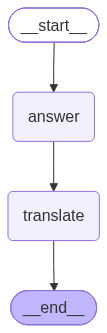

In [9]:
graph = parent_builder.compile()

graph

In [10]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics (also called quantum mechanics or quantum theory) is the branch of physics that describes how the universe works at the smallest scales—at the level of atoms and subatomic particles.\n\nHere’s a clear breakdown of what it is and why it’s so different from everyday physics.\n\n---\n\n### 1. The Core Idea: Energy Comes in Chunks\n\nClassical physics assumed that energy was continuous, like a ramp you could slide up or down smoothly. Quantum physics revealed that at tiny scales, energy is **quantized**—it comes in discrete packets called **quanta** (singular: quantum).\n\nThink of it like a staircase instead of a ramp. A particle can only stand on step 1, step 2, or step 3, but never in between.\n\n---\n\n### 2. Key Principles That Defy Intuition\n\nQuantum physics is famous for being strange. Its core principles challenge our everyday experience:\n\n- **Wave-Particle Duality:** Tiny entities like electrons and photon